## Task 1 - Pressure Sensor

In [65]:
import matplotlib.pyplot as plt
import numpy as np

pressure_data = []
t_data = []

with open("Data/Pressure.txt") as f:
    for line in f:
        pressure_data.append(float(line.split("Pressure:")[1].strip()))
        t_data.append(int(line.split("Timestamp:")[1].split("Pressure:")[0].strip()))

timestamp_data = [0] 
for i in range(1, len(t_data)):
    timestamp_data.append(timestamp_data[i-1] + (t_data[i] - t_data[i-1]))

timestamp_data = timestamp_data[:1000]
pressure_data = pressure_data[:1000]

print(pressure_data)
print(timestamp_data)


[97887.65, 97888.88, 97889.27, 97886.92, 97888.4, 97888.34, 97889.32, 97889.88, 97889.84, 97889.93, 97889.14, 97889.92, 97889.8, 97888.61, 97890.06, 97887.83, 97888.78, 97886.57, 97888.44, 97887.31, 97887.06, 97886.17, 97887.82, 97886.95, 97888.38, 97886.81, 97887.4, 97887.46, 97888.3, 97884.08, 97888.85, 97886.61, 97887.36, 97887.71, 97890.31, 97889.05, 97885.06, 97888.91, 97890.22, 97889.24, 97889.68, 97888.3, 97889.36, 97889.24, 97889.85, 97889.22, 97890.55, 97888.51, 97888.38, 97889.66, 97888.21, 97887.55, 97887.71, 97887.42, 97887.14, 97886.49, 97888.77, 97886.31, 97887.38, 97885.27, 97888.21, 97887.63, 97888.58, 97888.26, 97887.4, 97887.74, 97886.95, 97890.28, 97888.88, 97887.76, 97887.81, 97888.04, 97885.74, 97888.3, 97889.88, 97889.15, 97889.9, 97888.01, 97890.16, 97888.18, 97888.57, 97888.61, 97889.5, 97887.48, 97889.47, 97888.63, 97889.42, 97885.71, 97888.14, 97887.86, 97886.63, 97887.56, 97888.54, 97885.79, 97887.88, 97887.17, 97885.7, 97887.14, 97888.24, 97885.87, 97887.13,

Pressure Sensor
1. Write a program that measures every 100 ms the pressure and prints the values continuously on the serial interface. 
<br>
a. Ensure steady conditions for your sensor and record 1,000 pressure readings.
Can you observe any drift? Repeat the measurements to ensure representative
conditions.


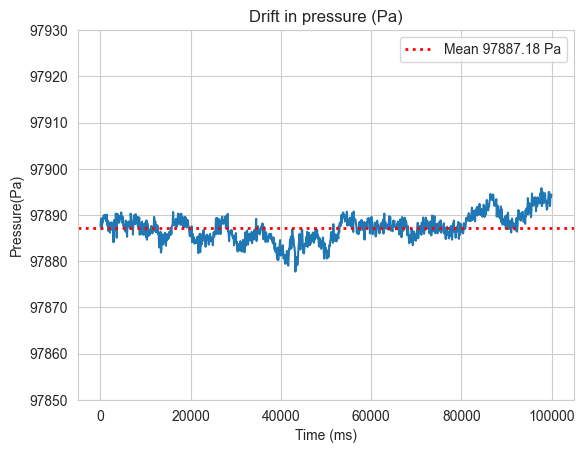

In [66]:
plt.plot(timestamp_data, pressure_data)
plt.ylim(97850,97930)
plt.axhline(np.mean(pressure_data), linestyle=":", linewidth=2, color="red", label=f"Mean {np.mean(pressure_data):.2f} Pa")
plt.title("Drift in pressure (Pa)")
plt.xlabel("Time (ms)")
plt.ylabel("Pressure(Pa)")
plt.grid(True)
plt.legend()
plt.show()



b. Convert the raw readings to pressure. Calculate the mean value 𝑝̅. What is the
offset (sensor reading at rest)? Is this value expected?


In [67]:
mean_pressure = round(sum(pressure_data)/len(pressure_data),3)
print(f"Mean Pressure (Pa): {mean_pressure}")

offset = []
offset = [round(p - mean_pressure, 3) for p in pressure_data]

print(f"Offset Values: {offset}")



Mean Pressure (Pa): 97887.183
Offset Values: [0.467, 1.697, 2.087, -0.263, 1.217, 1.157, 2.137, 2.697, 2.657, 2.747, 1.957, 2.737, 2.617, 1.427, 2.877, 0.647, 1.597, -0.613, 1.257, 0.127, -0.123, -1.013, 0.637, -0.233, 1.197, -0.373, 0.217, 0.277, 1.117, -3.103, 1.667, -0.573, 0.177, 0.527, 3.127, 1.867, -2.123, 1.727, 3.037, 2.057, 2.497, 1.117, 2.177, 2.057, 2.667, 2.037, 3.367, 1.327, 1.197, 2.477, 1.027, 0.367, 0.527, 0.237, -0.043, -0.693, 1.587, -0.873, 0.197, -1.913, 1.027, 0.447, 1.397, 1.077, 0.217, 0.557, -0.233, 3.097, 1.697, 0.577, 0.627, 0.857, -1.443, 1.117, 2.697, 1.967, 2.717, 0.827, 2.977, 0.997, 1.387, 1.427, 2.317, 0.297, 2.287, 1.447, 2.237, -1.473, 0.957, 0.677, -0.553, 0.377, 1.357, -1.393, 0.697, -0.013, -1.483, -0.043, 1.057, -1.313, -0.053, -2.023, 1.637, -2.543, 1.027, -0.483, -1.773, -1.053, -0.713, -1.523, -0.323, -0.233, -0.133, 0.427, 0.077, -1.183, 0.047, -0.163, 0.077, 2.387, -0.603, 1.477, 1.217, -0.903, -0.233, -0.953, 0.587, -0.163, -1.353, -1.373, -4


c. Show your data with subtracted mean value 𝑝 − 𝑝̅ in an appropriate histogram.
How are the values distributed? How do your results fit to the datasheet?

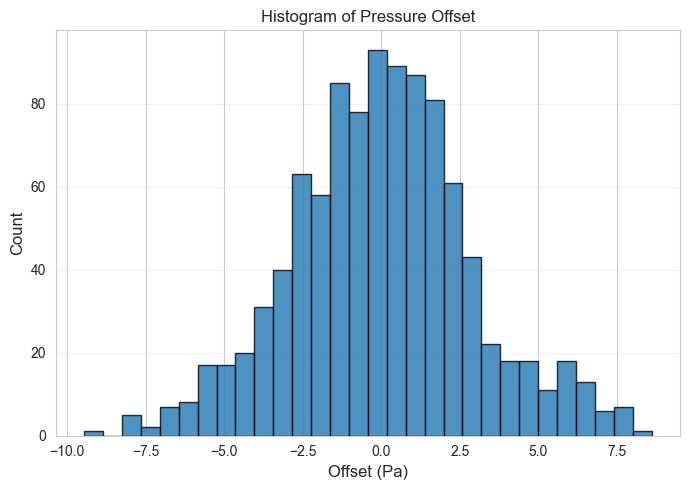

In [68]:
plt.figure(figsize=(7,5))
plt.hist(offset, bins=30, edgecolor="black", alpha=0.8)

plt.xlabel("Offset (Pa)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Histogram of Pressure Offset")
# plt.suptitle("Sample size 1000 at 100 ms interval")
plt.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()

## Task 2 - Acceleration Sensor

2. Write a program that measures every 100 ms the acceleration in all three directions
and prints the values continuously on the serial interface.
<br>
a. Ensure steady conditions for your sensor and record 1,000 acceleration readings. Can you observe any drift? Repeat the measurements to ensure representative conditions.Sensors Lab Course 2025/26 24 / 39


[    0   100   200   300   400   500   600   700   800   900  1000  1100
  1200  1300  1400  1500  1600  1700  1800  1900  2000  2100  2200  2300
  2400  2500  2600  2700  2800  2900  3000  3100  3200  3300  3400  3500
  3600  3700  3800  3900  4000  4100  4200  4300  4400  4500  4600  4700
  4800  4900  5000  5100  5200  5300  5400  5500  5600  5700  5800  5900
  6000  6100  6200  6300  6400  6500  6600  6700  6800  6900  7000  7100
  7200  7300  7400  7500  7600  7700  7800  7900  8000  8100  8200  8300
  8400  8500  8600  8700  8800  8900  9000  9100  9200  9300  9400  9500
  9600  9700  9800  9900 10000 10100 10200 10300 10400 10500 10600 10700
 10800 10900 11000 11100 11200 11300 11400 11500 11600 11700 11800 11900
 12000 12100 12200 12300 12400 12500 12600 12700 12800 12900 13000 13100
 13200 13300 13400 13500 13600 13700 13800 13900 14000 14100 14200 14300
 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500
 15600 15700 15800 15900 16000 16100 16200 16300 16

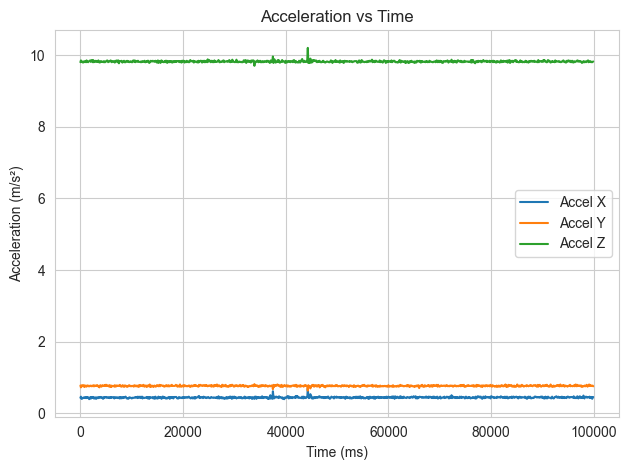

In [69]:
with open("Data/Acceleration.txt", "r") as f:
    lines = f.readlines()

timestamps_accel = []
accel_x = []
accel_y = []
accel_z = []

for line in lines:
    parts = line.split()
    t = int(parts[1])
    x = float(parts[3].split(":")[1])
    y = float(parts[5].split(":")[1])
    z = float(parts[7].split(":")[1])

    timestamps_accel.append(t)
    accel_x.append(x)
    accel_y.append(y)
    accel_z.append(z)

timestamps_accel = np.array([i * 100 for i in range(len(timestamps_accel))][:1000])
accel_x = np.array(accel_x[2000:3000])
accel_y = np.array(accel_y[2000:3000])
accel_z = np.array(accel_z[2000:3000])

print(timestamps_accel)
print(accel_x)
print(accel_y)
print(accel_z)

plt.plot(timestamps_accel, accel_x, label="Accel X")
plt.plot(timestamps_accel, accel_y, label="Accel Y")
plt.plot(timestamps_accel, accel_z, label="Accel Z")

plt.title("Acceleration vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration (m/s²)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


b. Calculate for each direction the mean value 𝑎̅. What is the offset in all three
directions (sensor reading at rest)? Do all three directions behave the same?
What could be a reason for the behavior?


Mean acceleration in X direction (m/s²): 0.437
Mean acceleration in Y direction (m/s²): 0.761
Mean acceleration in Z direction (m/s²): 9.829


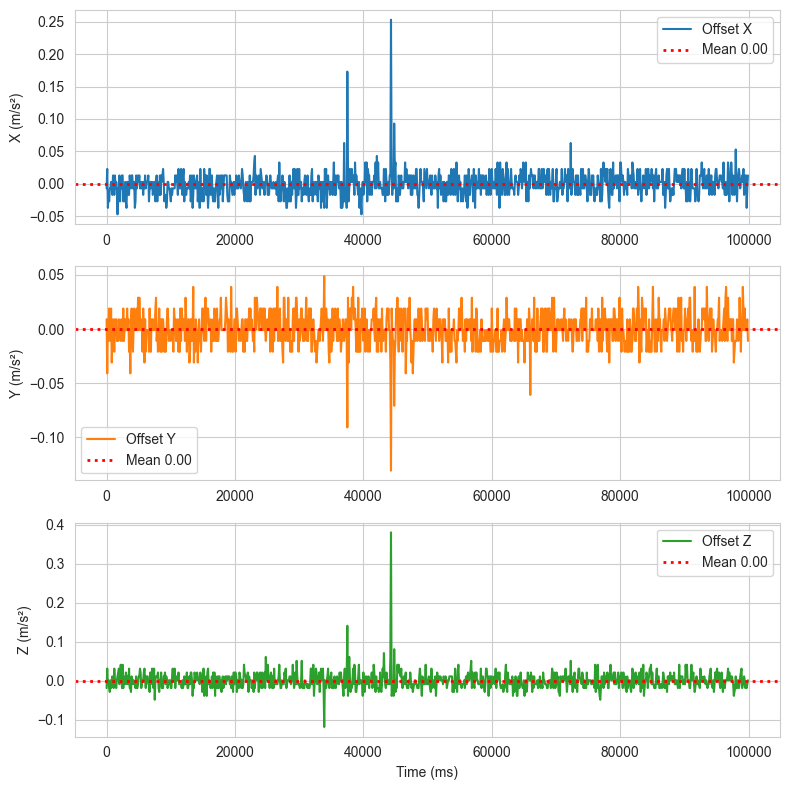

In [70]:
mean_x = round(np.mean(accel_x), 3)
mean_y = round(np.mean(accel_y), 3)
mean_z = round(np.mean(accel_z), 3)

print(f"Mean acceleration in X direction (m/s²): {mean_x}")
print(f"Mean acceleration in Y direction (m/s²): {mean_y}")
print(f"Mean acceleration in Z direction (m/s²): {mean_z}")

offset_x = np.round(accel_x - mean_x, 3)
offset_y = np.round(accel_y - mean_y, 3)
offset_z = np.round(accel_z - mean_z, 3)


plt.figure(figsize=(8,8))

# X
plt.subplot(3,1,1)
plt.plot(timestamps_accel, offset_x, color="C0", label="Offset X")
plt.axhline(np.mean(offset_x), linestyle=":", color="red", linewidth=2,label=f"Mean {abs(np.mean(offset_x)):.2f}")
plt.ylabel("X (m/s²)")
plt.grid(True)
plt.legend()

# Y
plt.subplot(3,1,2)
plt.plot(timestamps_accel, offset_y, color="C1", label="Offset Y")
plt.axhline(np.mean(offset_y), linestyle=":", color="red", linewidth=2,label=f"Mean {abs(np.mean(offset_y)):.2f}")
plt.ylabel("Y (m/s²)")
plt.grid(True)
plt.legend()

# Z
plt.subplot(3,1,3)
plt.plot(timestamps_accel, offset_z, color="C2", label="Offset Z")
plt.axhline(np.mean(offset_z), linestyle=":", color="red", linewidth=2,label=f"Mean {abs(np.mean(offset_z)):.2f}")
plt.ylabel("Z (m/s²)")
plt.xlabel("Time (ms)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()





c. Show your data with subtracted mean value 𝑎 − 𝑎̅ for all three directions in an
appropriate histogram. How are the values distributed? Do all three directions
behave the same? What could be a reason for the behavior?

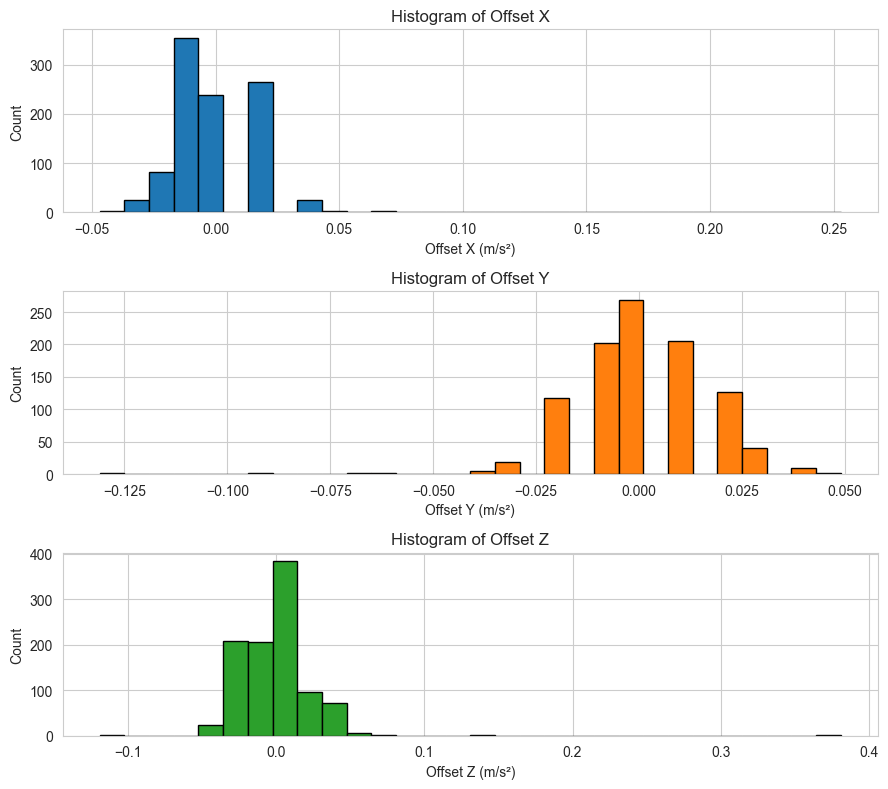

In [71]:
plt.figure(figsize=(9,8))

# X histogram
plt.subplot(3,1,1)
plt.hist(offset_x, bins=30, color="C0", edgecolor="black")
plt.title("Histogram of Offset X")
plt.xlabel("Offset X (m/s²)")
plt.ylabel("Count")
plt.grid(True)

# Y histogram
plt.subplot(3,1,2)
plt.hist(offset_y, bins=30, color="C1", edgecolor="black")
plt.title("Histogram of Offset Y")
plt.xlabel("Offset Y (m/s²)")
plt.ylabel("Count")
plt.grid(True)

# Z histogram
plt.subplot(3,1,3)
plt.hist(offset_z, bins=30, color="C2", edgecolor="black")
plt.title("Histogram of Offset Z")
plt.xlabel("Offset Z (m/s²)")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()


## Task 3 - Elevator Measurement

3. Write a program that measures the pressure and the acceleration in z-direction every
100 ms and prints the values continuously on the serial interface. Additionally, include
the time output since the controller start as a timestamp for each measurement.
<br>
a. Place your setup in an elevator (e.g., the elevator in lecture building 101). Make
sure that your board is parallel to the floor and does not move during the ride.
Start your measurement before the elevator moves. Ride the elevator from the
ground floor to another floor and back. Compare different the different directions
(upwards/downwards). Please ensure not to disturb other people.

[    0   100   200   300   400   500   600   700   800   900  1000  1100
  1200  1300  1400  1500  1600  1700  1800  1900  2000  2100  2200  2300
  2400  2500  2600  2700  2800  2900  3000  3100  3200  3300  3400  3500
  3600  3700  3800  3900  4000  4100  4200  4300  4400  4500  4600  4700
  4800  4900  5000  5100  5200  5300  5400  5500  5600  5700  5800  5900
  6000  6100  6200  6300  6400  6500  6600  6700  6800  6900  7000  7100
  7200  7300  7400  7500  7600  7700  7800  7900  8000  8100  8200  8300
  8400  8500  8600  8700  8800  8900  9000  9100  9200  9300  9400  9500
  9600  9700  9800  9900 10000 10100 10200 10300 10400 10500 10600 10700
 10800 10900 11000 11100 11200 11300 11400 11500 11600 11700 11800 11900
 12000 12100 12200 12300 12400 12500 12600 12700 12800 12900 13000 13100
 13200 13300 13400 13500 13600 13700 13800 13900 14000 14100 14200 14300
 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500
 15600 15700 15800 15900 16000 16100 16200 16300 16

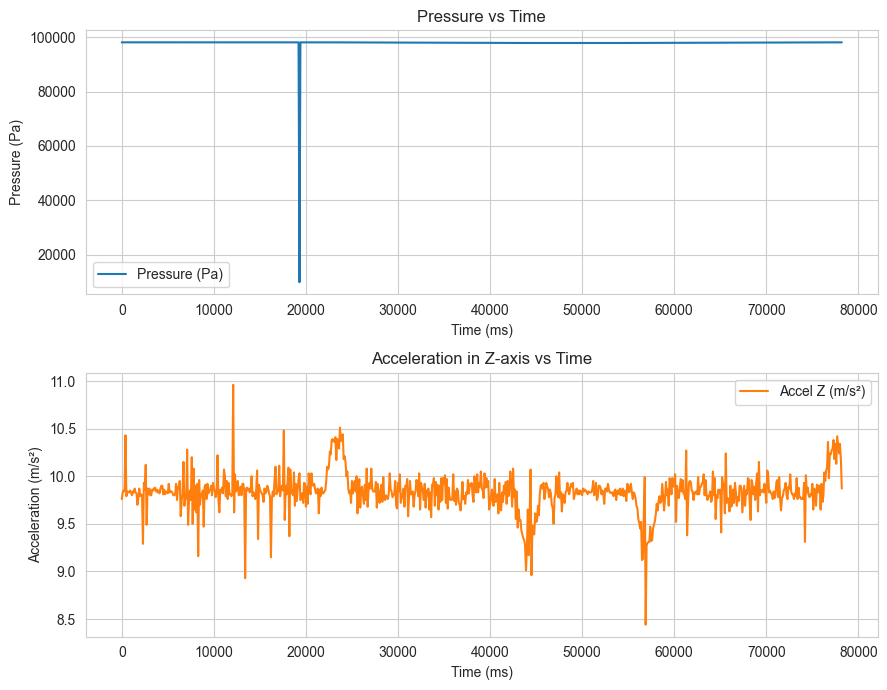

In [72]:
elev_timestamp = []
elev_accel_z = []
elev_pressure = []

with open("Data/ElevatorRIde.txt") as f:
    for line in f:

        line = line.strip()
        if line == "":
            continue

        # timestamp
        ts_start = line.find("Timestamp:") + len("Timestamp:")
        ts_end = line.find("Acceleration")
        t = int(line[ts_start:ts_end].strip())

        # accel z
        az_start = line.find("z-axis:") + len("z-axis:")
        az_end = line.find("Pressure:")
        az = float(line[az_start:az_end].strip())

        # pressure
        p_start = line.find("Pressure:") + len("Pressure:")
        p = float(line[p_start:].strip())

        elev_timestamp.append(t)
        elev_accel_z.append(az)
        elev_pressure.append(p)

elev_timestamp = np.array([i * 100 for i in range(len(elev_timestamp))])
elev_accel_z = np.array(elev_accel_z)
elev_pressure = np.array(elev_pressure)

print(elev_timestamp)
print(elev_accel_z)
print(elev_pressure)

plt.figure(figsize=(9,7))

# Pressure subplot
plt.subplot(2,1,1)
plt.plot(elev_timestamp, elev_pressure, color="C0", label="Pressure (Pa)")
plt.title("Pressure vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Pressure (Pa)")
plt.grid(True)
plt.legend()

# Acceleration Z subplot
plt.subplot(2,1,2)
plt.plot(elev_timestamp, elev_accel_z, color="C1", label="Accel Z (m/s²)")
plt.title("Acceleration in Z-axis vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration (m/s²)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


b. Evaluate the pressure data using the barometric formula (eq. 1.1) to describe
the height of your rides in a diagram (height vs. time)

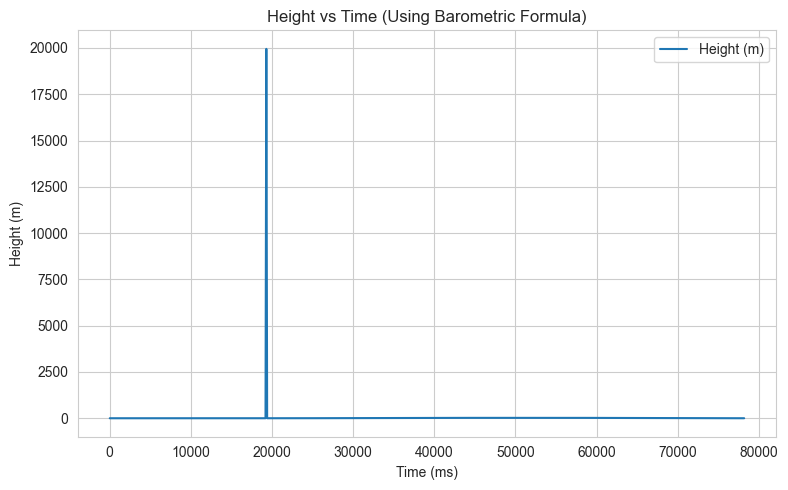

In [73]:
p0 = elev_pressure[0]   # reference pressure
g = 9.81
M = 0.02896
R = 8.314
T = 23 + 273            # Kelvin

# height from pressure (array)
h = -(R * T) / (g * M) * np.log(elev_pressure / p0)

plt.figure(figsize=(8,5))
plt.plot(elev_timestamp, h, label = 'Height (m)')
plt.xlabel("Time (ms)")
plt.ylabel("Height (m)")
plt.title("Height vs Time (Using Barometric Formula)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


c. Integrate the acceleration sensor data to show the velocity of your rides in a
diagram (velocity vs. time).

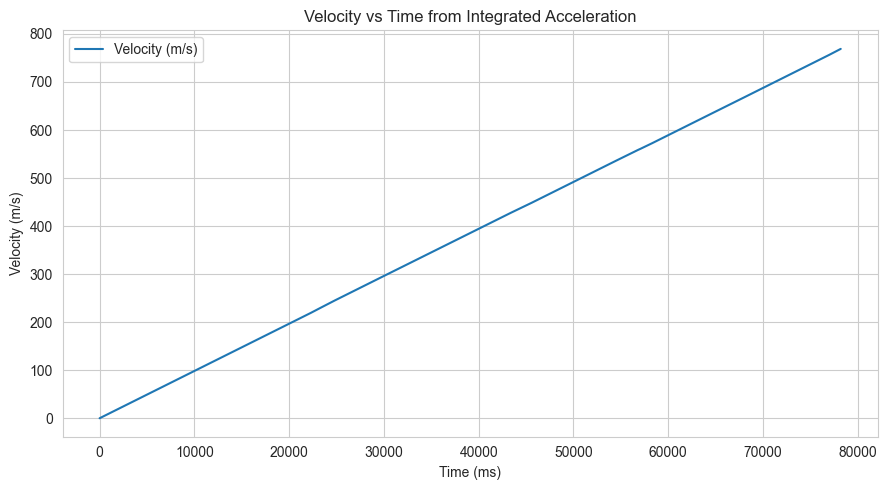

In [74]:
dt = 0.1  # 100 ms sampling interval

velocity = np.zeros_like(elev_accel_z)

for i in range(1, len(elev_accel_z)):
    velocity[i] = velocity[i-1] + elev_accel_z[i] * dt

plt.figure(figsize=(9,5))
plt.plot(elev_timestamp, velocity, label="Velocity (m/s)")
plt.xlabel("Time (ms)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity vs Time from Integrated Acceleration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


d. Integrate the acceleration sensor twice to show the height of your rides in a
diagram (height vs. time) together with readings from the pressure sensor. Discuss which approach suits better if you want to track the height during your
elevator rides.

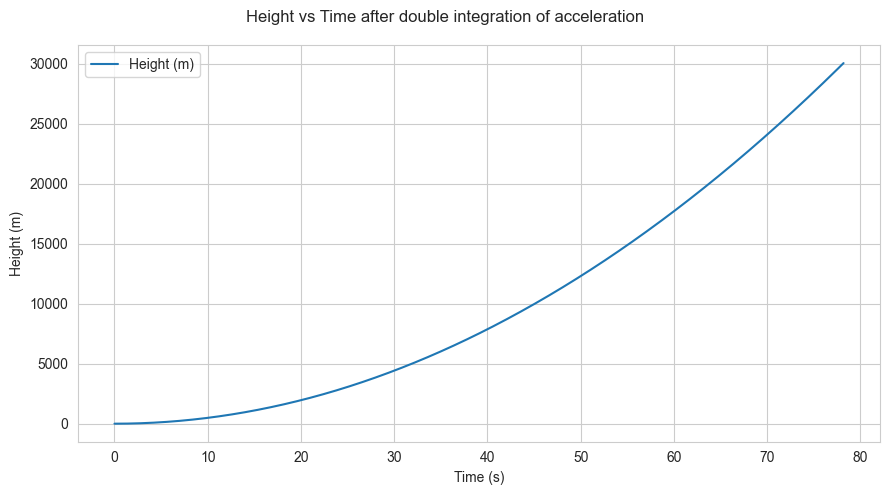

In [75]:
# convert timestamp to seconds
timestamps_sec = elev_timestamp / 1000

# initialize height array
height_accel = np.zeros_like(velocity)

# integrate velocity to height
for i in range(1, len(timestamps_sec)):
    dt = timestamps_sec[i] - timestamps_sec[i - 1]     # time difference in seconds
    height_accel[i] = height_accel[i - 1] + velocity[i - 1] * dt

# plotting
plt.figure(figsize=(9,5))
plt.suptitle("Height vs Time after double integration of acceleration")

plt.plot(timestamps_sec, height_accel, label="Height (m)")

plt.xlabel("Time (s)")
plt.ylabel("Height (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
